PyTorch Geometric Tutorial

PyTorch Geometric (PyG) is an extension library for PyTorch. It provides useful primitives to develop Graph Deep Learning models, including various graph neural network layers and a large number of benchmark datasets.

In [1]:
import torch
print("PyTorch has version {}".format(torch.__version__))

PyTorch has version 2.8.0+cu129


Visualization

In [2]:
# Helper function for visualization.
%matplotlib inline
import torch
import networkx as nx
import matplotlib.pyplot as plt

# Visualization function for NX graph or PyTorch tensor
def visualize(h, color, epoch=None, loss=None, accuracy=None):
    plt.figure(figsize=(7,7))
    plt.xticks([])
    plt.yticks([])

    if torch.is_tensor(h):
        h = h.detach().cpu().numpy()
        plt.scatter(h[:, 0], h[:, 1], s=140, c=color, cmap="Set2")
        if epoch is not None and loss is not None and accuracy['train'] is not None and accuracy['val'] is not None:
            plt.xlabel((f'Epoch: {epoch}, Loss: {loss.item():.4f} \n'
                       f'Training Accuracy: {accuracy["train"]*100:.2f}% \n'
                       f' Validation Accuracy: {accuracy["val"]*100:.2f}%'),
                       fontsize=16)
    else:
        nx.draw_networkx(h, pos=nx.spring_layout(h, seed=42), with_labels=False,
                         node_color=color, cmap="Set2")
    plt.show()

Introduction

Recently, deep learning on graphs has emerged to one of the hottest research fields in the deep learning community. Here, Graph Neural Networks (GNNs) aim to generalize classical deep learning concepts to irregularly structured data (in contrast to images or texts) and to enable neural networks to reason about objects and their relations.

This tutorial will introduce you to some fundamental concepts regarding deep learning on graphs via Graph Neural Networks based on the PyTorch Geometric (PyG) library. PyTorch Geometric is an extension library to the popular deep learning framework PyTorch, and consists of various methods and utilities to simplify the implementation of Graph Neural Networks.

Following Kipf et al. (2017), let's dive into the world of GNNs by looking at a simple graph-structured example, the well-known Zachary's karate club network. This graph describes a social network of 34 members of a karate club and documents links between members who interacted outside the club. Here, we are interested in detecting communities that arise from the member's interaction.

Dataset

PyTorch Geometric provides an easy access to the dataset via the torch_geometric.datasets subpackage:

*KarateClub dataset has 34 person*

*Class - members were split into 4 groups (clusters)*

After initializing the KarateClub dataset, we first can inspect some of its properties. For example, we can see that this dataset holds exactly one graph, and that each node in this dataset is assigned a 34-dimensional feature vector (which uniquely describes the members of the karate club). Furthermore, the graph holds exactly 4 classes, which represent the community each node belongs to.



In [3]:
from torch_geometric.datasets import KarateClub

dataset = KarateClub()
print(f'Dataset: {dataset}:')
print('======================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

/home/hice1/pmaji3/scratch/gnn02/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset: KarateClub():
Number of graphs: 1
Number of features: 34
Number of classes: 4


Even though we have 34 nodes in the total graph, we are allowed to use the labels (class) for 4 specific nodes to calculate the loss and update wieghts. The other 30 nodes are treated as "unlabeled" during training, even though their edges are still visible.

4 train nodes (data.train_mask)

30 validation / test nodes.

In [4]:
data = dataset[0]  # Get the first graph object.

print(data)
print('==============================================================')

# Gather some statistics about the graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {(data.num_edges) / data.num_nodes:.2f}')
print(f'Number of training nodes: {data.train_mask.sum()}')
print(f'Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}')
print(f'Contains isolated nodes: {data.has_isolated_nodes()}')
print(f'Contains self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
Number of nodes: 34
Number of edges: 156
Average node degree: 4.59
Number of training nodes: 4
Training node label rate: 0.12
Contains isolated nodes: False
Contains self-loops: False
Is undirected: True


**Why so few? (Training node label rate: 0.12)**

This is a "Semi-Supervised" learning setup.
In the Karate Club, the goal is to see if the model can learn the structure of the entire graph using only a tiny bit of information.
Think of it like this: You know the political leanings of 4 people in a club, and you know who everyone's friends are. Can you guess the leanings of the other 30 people based solely on who they hang out with?

**Data**
Each graph in PyTorch Geometric is represented by a single Data object, which holds all the information to describe its graph representation. We can print the data object anytime via print(data) to receive a short summary about its attributes and their shapes:

Data(edge_index=[2, 156], x=[34, 34], y=[34], train_mask=[34])

We can see that this data object holds 4 attributes: 
(1) The edge_index property holds the information about the graph connectivity, i.e., a tuple of source and destination node indices for each edge. 
PyG further refers to (2) node features as x (each of the 34 nodes is assigned a 34-dim feature vector), and to 
(3) node labels as y (each node is assigned to exactly one class). 
(4) There also exists an additional attribute called train_mask, which describes for which nodes we already know their community assigments. In total, we are only aware of the ground-truth labels of 4 nodes (one for each community), and the task is to infer the community assignment for the remaining nodes.

The data object also provides some utility functions to infer some basic properties of the underlying graph. For example, we can easily infer whether there exists isolated nodes in the graph (i.e. there exists no edge to any node), whether the graph contains self-loops (i.e., (v,v)∈E), or whether the graph is undirected (i.e., for each edge (v,w)∈E there also exists the edge (w,v)∈E).

In [5]:
print(data)

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])


In [6]:
print(data.x)

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])


In [7]:
#4 classes 0 - 4
print(data.y)

tensor([1, 1, 1, 1, 3, 3, 3, 1, 0, 1, 3, 1, 1, 1, 0, 0, 3, 1, 0, 1, 0, 1, 0, 0,
        2, 2, 0, 0, 2, 0, 0, 2, 0, 0])


In [8]:
print(data.edge_index.t())

tensor([[ 0,  1],
        [ 0,  2],
        [ 0,  3],
        [ 0,  4],
        [ 0,  5],
        [ 0,  6],
        [ 0,  7],
        [ 0,  8],
        [ 0, 10],
        [ 0, 11],
        [ 0, 12],
        [ 0, 13],
        [ 0, 17],
        [ 0, 19],
        [ 0, 21],
        [ 0, 31],
        [ 1,  0],
        [ 1,  2],
        [ 1,  3],
        [ 1,  7],
        [ 1, 13],
        [ 1, 17],
        [ 1, 19],
        [ 1, 21],
        [ 1, 30],
        [ 2,  0],
        [ 2,  1],
        [ 2,  3],
        [ 2,  7],
        [ 2,  8],
        [ 2,  9],
        [ 2, 13],
        [ 2, 27],
        [ 2, 28],
        [ 2, 32],
        [ 3,  0],
        [ 3,  1],
        [ 3,  2],
        [ 3,  7],
        [ 3, 12],
        [ 3, 13],
        [ 4,  0],
        [ 4,  6],
        [ 4, 10],
        [ 5,  0],
        [ 5,  6],
        [ 5, 10],
        [ 5, 16],
        [ 6,  0],
        [ 6,  4],
        [ 6,  5],
        [ 6, 16],
        [ 7,  0],
        [ 7,  1],
        [ 7,  2],
        [ 

By printing edge_index, we can further understand how PyG represents graph connectivity internally. We can see that for each edge, edge_index holds a tuple of two node indices, where the first value describes the node index of the source node and the second value describes the node index of the destination node of an edge.

This representation is known as the COO format (coordinate format) commonly used for representing sparse matrices. Instead of holding the adjacency information in a dense representation  A∈{0,1}|V|×|V| , PyG represents graphs sparsely, which refers to only holding the coordinates/values for which entries in  A  are non-zero.

We can further visualize the graph by converting it to the networkx library format, which implements, in addition to graph manipulation functionalities, powerful tools for visualization:

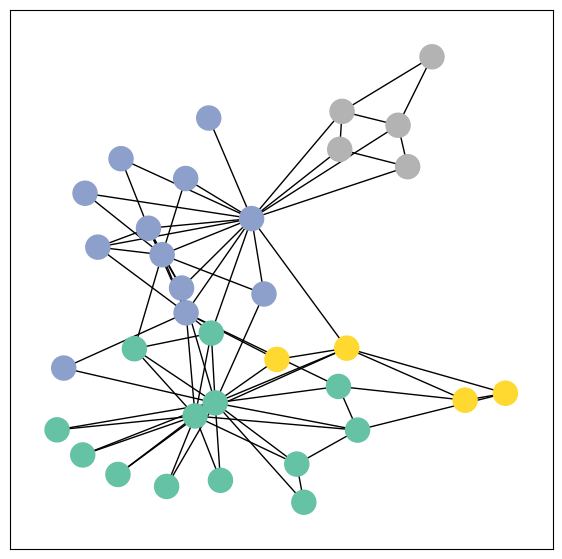

In [9]:
from torch_geometric.utils import to_networkx

G = to_networkx(data, to_undirected=True)
visualize(G, color=data.y)

In [10]:
from KarateClub import GNN

model = GNN(dataset=dataset)
print(model)

GNN(
  (conv1): GCNConv(34, 4)
  (conv2): GCNConv(4, 4)
  (conv3): GCNConv(4, 2)
  (fc): Linear(in_features=2, out_features=4, bias=True)
)


Before training

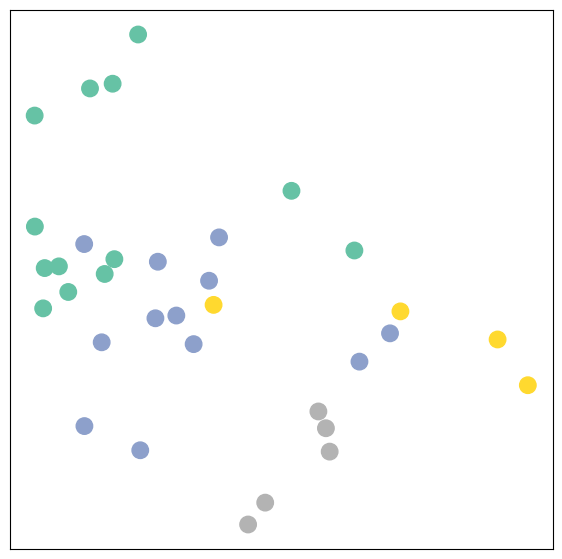

In [11]:
model = GNN(dataset=dataset)
_, h = model(data.x, data.edge_index)
visualize(h, color=data.y)

Training on the Karate Club Network

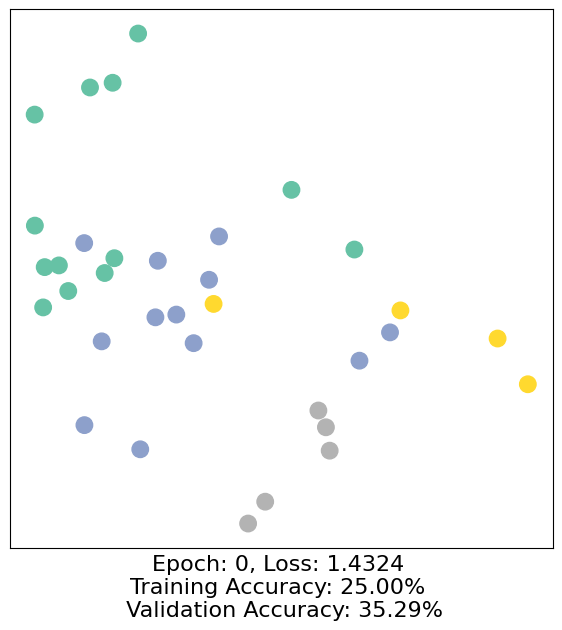

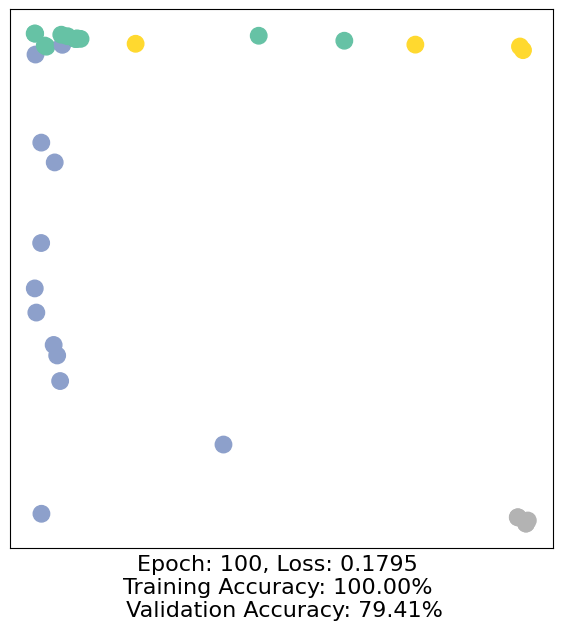

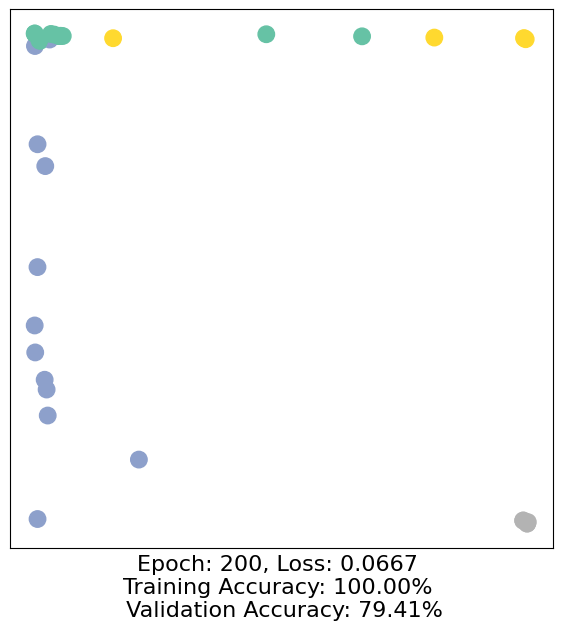

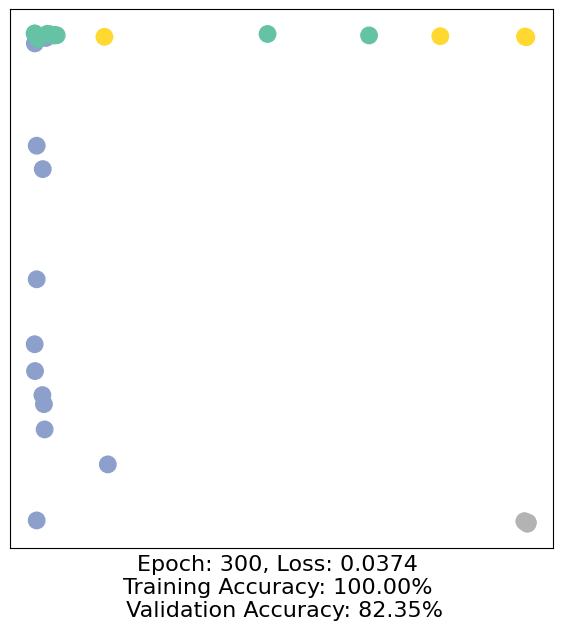

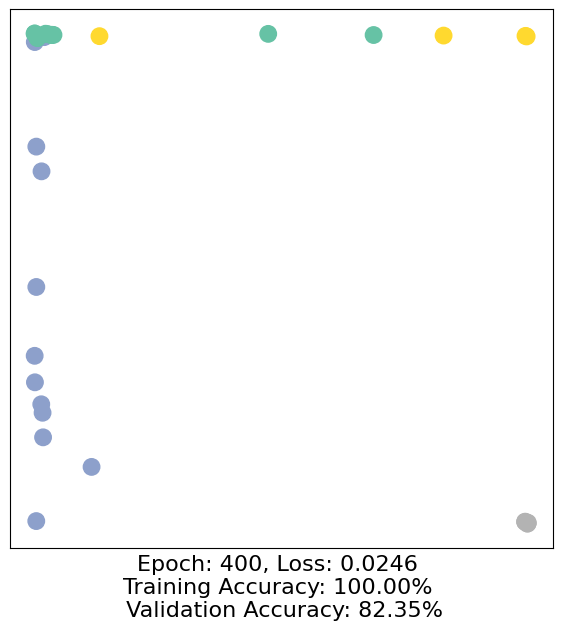

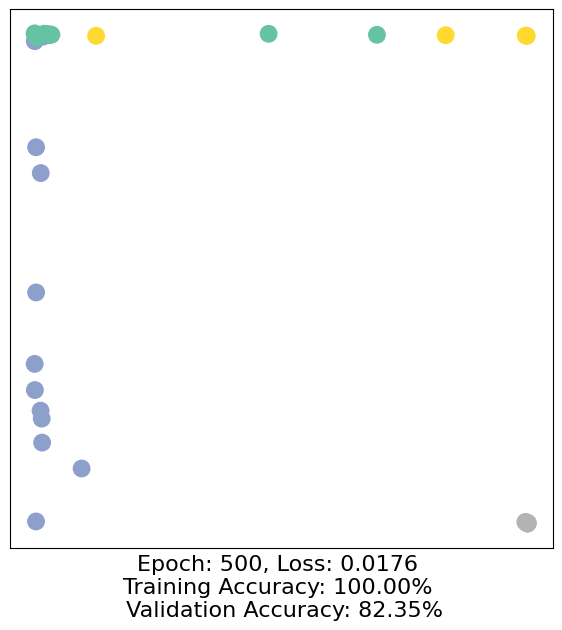

In [12]:
from trainer import TrainerBasicGNN
model = GNN(dataset=dataset)
data = dataset[0]
trainer = TrainerBasicGNN(model=model, data=data)

for epoch in range(501):
    loss, h, accuracy = trainer.train()
    if epoch % 100 == 0:
        visualize(h, color=data.y, epoch=epoch, loss=loss, accuracy=accuracy)

